# Copyright (c) Meta Platforms, Inc. and affiliates.


## Image segmentation with EfficientSAM3

This notebook demonstrates how to use EfficientSAM3 for image segmentation with text or visual prompts. It covers the following capabilities:

- **Text prompts**: Using natural language descriptions to segment objects (e.g., "person", "face")
- **Box prompts**: Using bounding boxes as exemplar visual prompts


# <a target="_blank" href="https://colab.research.google.com/github/SimonZeng7108/efficientsam3/blob/main/efficientsam3_examples/efficientsam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>


In [21]:
using_colab = False


In [22]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/SimonZeng7108/efficientsam3.git'


In [23]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import matplotlib.pyplot as plt
import numpy as np

import sam3
from PIL import Image
from sam3.model.box_ops import box_xywh_to_cxcywh
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results

sam3_root = os.path.join(os.path.dirname(sam3.__file__), "..")

In [24]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()


# Build Model
Note: When using a merged checkpoint (containing both image and text student encoders), you must specify the `backbone_type`, `model_name`, and `text_encoder_type` to ensure the correct architecture is built.


In [ ]:
from sam3.model_builder import build_efficientsam3_image_model

bpe_path = f"{sam3_root}/assets/bpe_simple_vocab_16e6.txt.gz"
context_length = 16
pos_embed_table_size = context_length  # fixed default
model = build_efficientsam3_image_model(
    bpe_path=bpe_path,
    checkpoint_path=f"{sam3_root}/../efficient_sam3_repvit_m1.1_mobileclip_s1_merged.pth",
    load_from_HF=False,
    backbone_type="repvit",
    model_name="m1.1",
    text_encoder_type="MobileCLIP-S1",
    text_encoder_context_length=context_length,
    text_encoder_pos_embed_table_size=pos_embed_table_size,
    interpolate_pos_embed=False,
)

loaded /home/simon7108528_msi_linux/e-drive/side_projects/efficientsam3/output/efficient_sam3_repvit_m1.1_mobileclip_s1_merged.pth and found missing keys: 6 and unexpected keys: 1730.
Sample missing: ['backbone.vision_backbone.trunk.model.backbone.model.classifier.classifier.bn.weight', 'backbone.vision_backbone.trunk.model.backbone.model.classifier.classifier.bn.bias', 'backbone.vision_backbone.trunk.model.backbone.model.classifier.classifier.bn.running_mean', 'backbone.vision_backbone.trunk.model.backbone.model.classifier.classifier.bn.running_var', 'backbone.vision_backbone.trunk.model.backbone.model.classifier.classifier.l.weight']


In [26]:
image_path = f"{sam3_root}/assets/images/test_image.jpg"
image = Image.open(image_path)
width, height = image.size
processor = Sam3Processor(model, confidence_threshold=0.5)
inference_state = processor.set_image(image)


# Text prompt


found 8 object(s)


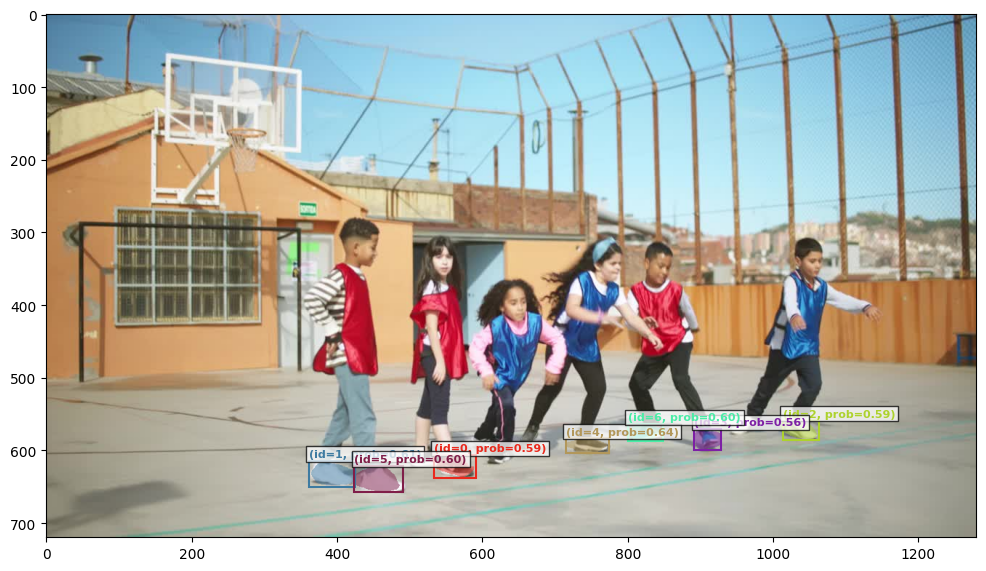

In [27]:
processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="a shoe")

img0 = Image.open(image_path)
plot_results(img0, inference_state)


### Visual prompt: a single bounding box


Normalized box input: [0.41796875, 0.6527777910232544, 0.0859375, 0.5]


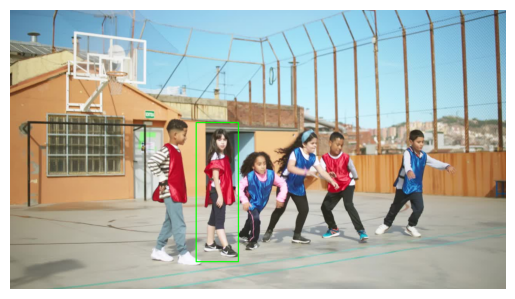

In [28]:
# Here the box is in  (x,y,w,h) format, where (x,y) is the top left corner.
box_input_xywh = torch.tensor([480.0, 290.0, 110.0, 360.0]).view(-1, 4)
box_input_cxcywh = box_xywh_to_cxcywh(box_input_xywh)

norm_box_cxcywh = normalize_bbox(box_input_cxcywh, width, height).flatten().tolist()
print("Normalized box input:", norm_box_cxcywh)

processor.reset_all_prompts(inference_state)
inference_state = processor.add_geometric_prompt(
    state=inference_state, box=norm_box_cxcywh, label=True
)

img0 = Image.open(image_path)
image_with_box = draw_box_on_image(img0, box_input_xywh.flatten().tolist())
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.show()


found 4 object(s)


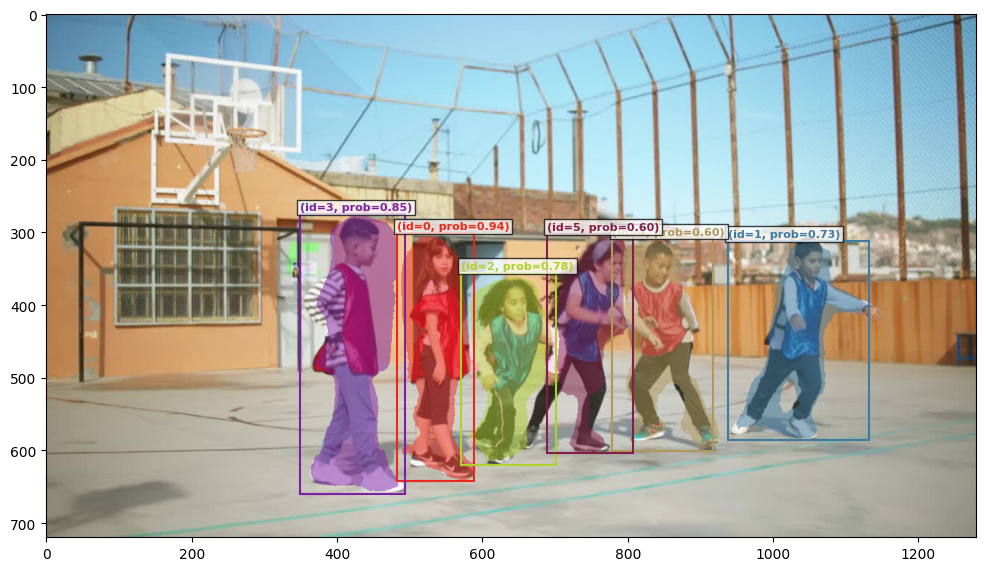

In [29]:
plot_results(img0, inference_state)


### Visual prompt: multi-box prompting (with positive and negative boxes)


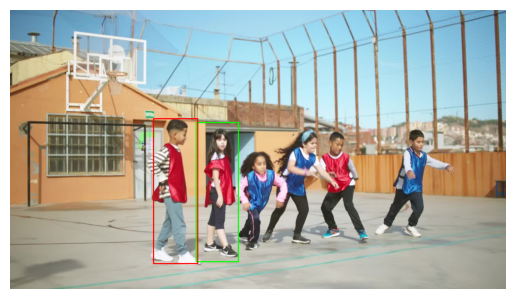

In [30]:
box_input_xywh = [[480.0, 290.0, 110.0, 360.0], [370.0, 280.0, 115.0, 375.0]]
box_input_cxcywh = box_xywh_to_cxcywh(torch.tensor(box_input_xywh).view(-1,4))
norm_boxes_cxcywh = normalize_bbox(box_input_cxcywh, width, height).tolist()

box_labels = [True, False]

processor.reset_all_prompts(inference_state)

for box, label in zip(norm_boxes_cxcywh, box_labels):
    inference_state = processor.add_geometric_prompt(
        state=inference_state, box=box, label=label
    )

img0 = Image.open(image_path)
image_with_box = img0
for i in range(len(box_input_xywh)):
    if box_labels[i] == 1:
        color = (0, 255, 0)
    else:
        color = (255, 0, 0)
    image_with_box = draw_box_on_image(image_with_box, box_input_xywh[i], color)
plt.imshow(image_with_box)
plt.axis("off")  # Hide the axis
plt.show()


found 2 object(s)


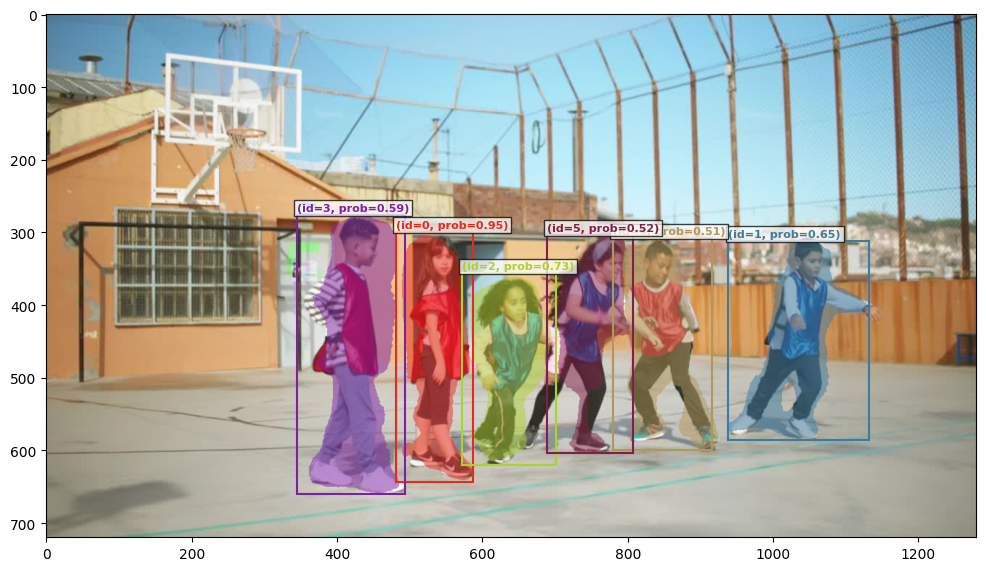

In [31]:
plot_results(img0, inference_state)
